Classification Report for Logistic Regression:
               precision    recall  f1-score   support

           0       0.84      0.86      0.85       140
           1       0.75      0.72      0.74        83

    accuracy                           0.81       223
   macro avg       0.79      0.79      0.79       223
weighted avg       0.81      0.81      0.81       223

survival rate of the people on the titanic:  80.71748878923766

Classification Report for Decision Tree:
               precision    recall  f1-score   support

           0       0.84      0.88      0.86       140
           1       0.78      0.72      0.75        83

    accuracy                           0.82       223
   macro avg       0.81      0.80      0.81       223
weighted avg       0.82      0.82      0.82       223

Accuracy Score for Decision Tree: 82.06%

Classification Report for k-Nearest Neighbors:
               precision    recall  f1-score   support

           0       0.74      0.81      0.77    

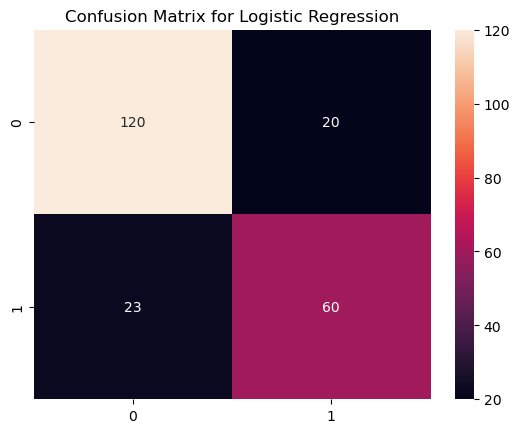

In [1]:
import pandas as pd 
import numpy as np
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report


df=pd.read_csv("Cleaned_Titanic_Dataset.csv")

X=df.drop(columns=["Survived"])
y=df["Survived"]

X_train,X_test,y_train,y_test= train_test_split(X,y , test_size=0.25 )
train_test_split



model=LogisticRegression(max_iter=1000)
model.fit(X_train,y_train)

y_pred=model.predict(X_test)

classifier=classification_report(y_test,y_pred)

print("Classification Report for Logistic Regression:\n", classifier)

score = accuracy_score(y_test,y_pred)
print("survival rate of the people on the titanic: ",score*100)

from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

dt_model = DecisionTreeClassifier()

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

classifier_report_dt = classification_report(y_test, y_pred_dt)

print("\nClassification Report for Decision Tree:\n", classifier_report_dt)

accuracy_score_dt = accuracy_score(y_test, y_pred_dt)

print(f"Accuracy Score for Decision Tree: {accuracy_score_dt* 100:.2f}%")

knn_model = KNeighborsClassifier()

knn_model.fit(X_train, y_train)

y_pred_knn = knn_model.predict(X_test)

classifier_report_knn = classification_report(y_test, y_pred_knn)

print("\nClassification Report for k-Nearest Neighbors:\n", classifier_report_knn)

accuracy_score_knn = accuracy_score(y_test, y_pred_knn)

print(f"Accuracy Score for k-NN: {accuracy_score_knn * 100:.2f}%")

from sklearn.metrics import confusion_matrix

conf_matrix_lr = sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')

conf_matrix_lr.set_title('Confusion Matrix for Logistic Regression')

plt.show()

### mini project2 : House Price Pridiction Model

In [2]:
import pandas as pd 
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

df=pd.read_csv("Housing.csv")
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [33]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

df = pd.get_dummies(df, columns=['hotwaterheating','mainroad','airconditioning','guestroom','basement','prefarea','furnishingstatus'], drop_first=True)
df.head(10)

,price,area,bedrooms,bathrooms,parking,hotwaterheating_yes,mainroad_yes,airconditioning_yes,guestroom_yes,basement_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,2,False,True,True,False,False,True,False,False
1,12250000,8960,4,4,3,False,True,True,False,False,False,False,False
2,12250000,9960,3,2,2,False,True,False,False,True,True,True,False
3,12215000,7500,4,2,3,False,True,True,False,True,True,False,False
4,11410000,7420,4,1,2,False,True,True,True,True,False,False,False
5,10850000,7500,3,3,2,False,True,True,False,True,True,True,False
6,10150000,8580,4,3,2,False,True,True,False,False,True,True,False
7,10150000,16200,5,3,0,False,True,False,False,False,False,False,True
8,9870000,8100,4,1,2,False,True,True,True,True,True,False,False
9,9800000,5750,3,2,1,False,True,True,True,False,True,False,True


In [15]:
df.drop(columns=['stories'],axis=1, inplace=True )

df.to_csv('Cleaned_housing.csv', index=False)
print("Project Complete! 'Cleaned_housing.csv' has been generated in your workspace.")
df

Project Complete! 'Cleaned_housing.csv' has been generated in your workspace.


,price,area,bedrooms,bathrooms,parking,hotwaterheating_yes,mainroad_yes,airconditioning_yes,guestroom_yes,basement_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,2,False,True,True,False,False,True,False,False
1,12250000,8960,4,4,3,False,True,True,False,False,False,False,False
2,12250000,9960,3,2,2,False,True,False,False,True,True,True,False
3,12215000,7500,4,2,3,False,True,True,False,True,True,False,False
4,11410000,7420,4,1,2,False,True,True,True,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,2,False,True,False,False,True,False,False,True
541,1767150,2400,3,1,0,False,False,False,False,False,False,True,False
542,1750000,3620,2,1,0,False,True,False,False,False,False,False,True
543,1750000,2910,3,1,0,False,False,False,False,False,False,False,False


house price prediction:  62.166511065152086



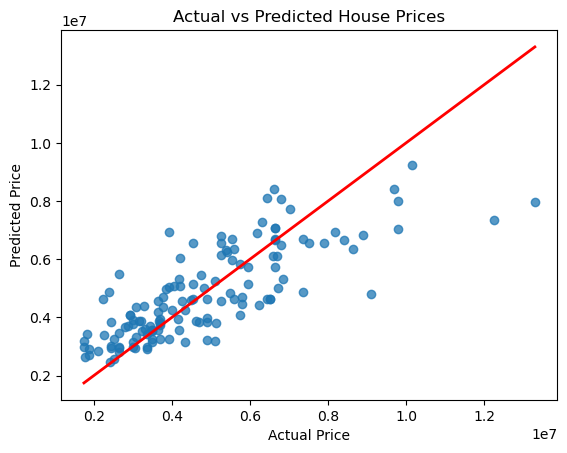

In [13]:
df=pd.read_csv("Cleaned_housing.csv")

X=df.drop(columns=["price"])
y=df["price"]

X_train,X_test,y_train,y_test= train_test_split(X,y , test_size=0.25 ,random_state=42)
train_test_split

model=LinearRegression()
model.fit(X_train,y_train)

y_pred=model.predict(X_test)



score = r2_score(y_test,y_pred)
print("house price prediction: ",score*100)

print()

plt.scatter(y_test, y_pred, alpha=0.75)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linewidth=2)
plt.title("Actual vs Predicted House Prices")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.show()

